# Week 6 (07-20-2026)

## Outlier Analysis: The High-Mass End of the $M_{\rm BH}$–$\sigma_\star$ Relation

We have now built an updated dataset combining the McConnell & Ma (2013) sample of 73 galaxies with ~20 new dynamical BH mass measurements of $\log(M_{\rm BH}/M_\odot) > 9$, compiled from the literature. 

You have also refit the $M_{\rm BH}$–$\sigma_\star$ relation for the full updated sample and for early-type galaxies separately.

 Now we want to know: **which galaxies deviate most from the best-fit relation, and what can we learn from them?**

This is an important question at the high-mass end specifically. The scatter in the $M_{\rm BH}$–$\sigma_\star$ relation is largest for the most massive galaxies, and several of the most extreme systems -- NGC 4889, Holm 15A, 4C+37.11 -- have disputed or highly uncertain BH masses. Understanding *why* some galaxies are outliers, whether it is physical or observational, is one of the open questions in the field.

---

## Goals for this analysis

1. Compute residuals from the best-fit $M_{\rm BH}$–$\sigma_\star$ relation
2. Identify outliers using a quantitative threshold
3. Visualize the residuals and flag the outliers on the $M_{\rm BH}$–$\sigma_\star$ diagram
4. Characterize the outliers: do they share morphological type, measurement method, or position in $\sigma$?
5. Investigate two outliers in the literature and write up what you find
6. Discuss what the outliers tell us about the high-mass end of the relation

---

## Before you start

This notebook picks up directly from your updated dataset and fits. Make sure the following variables are available before running any cell here — either re-run your previous notebook first, or copy the relevant arrays into the setup cell below:

- `log_sigma_full` — $\log_{10}(\sigma / \rm{km\ s}^{-1})$ for the full combined sample
- `log_mbh_full` — $\log_{10}(\rm{M}_{\rm BH} / \rm{M}_\odot)$ for the full combined sample
- `names` — galaxy names
- `morph` — morphological types
- `source` — source label for each galaxy (`'MM13'`, `'MM13_updated'`, or `'New'`)
- `slope`, `intercept` — from your best-fit linear regression on the full combined sample

Run a quick print check in the cell below to confirm everything is loaded.

In [1]:
# Setup: imports and quick check that all arrays are available
# Add any additional imports you need here

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

In [2]:
df=pd.read_csv("MBH_table_final.csv")
log_sigma_full=np.log10(df["sigma"]/200)
log_mbh_full=np.log10(df["M_BH"])
slope, intercept=np.polyfit(log_sigma_full,log_mbh_full,1)
df


,Galaxy,M_BH,M_BH_lower,M_BH_upper,sigma,Morph,Method,Source,Paper reference,MASSIVE?,BCG?,Limits source (for filled rows only)
0,A1836,3900000000,3300000000,4300000000,288.0,E,gas,MM13,NaN,NaN,NaN,NaN
1,A3565,1400000000,1200000000,1700000000,322.0,E,gas,MM13,NaN,NaN,NaN,NaN
2,CIRC,1700000,1400000,2100000,158.0,S,maser,MM13,NaN,NaN,NaN,NaN
3,IC1459,2800000000,1600000000,3900000000,315.0,E,star,MM13,NaN,NaN,NaN,NaN
4,MW,4100000,3500000,4700000,103.0,S,star,MM13,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
87,NGC4751,1400000000,1300000000,1500000000,355.4,E/S0,star,New,Rusli+13,NaN,NaN,NaN
88,NGC6861,2000000000,1800000000,2200000000,388.8,E/S0,star,New,Rustli+13,NaN,NaN,NaN
89,NGC5419,10000000000,9200000000,10800000000,350.0,E,star tri,New,Neureiter+23,NaN,NaN,NaN
90,NGC 3258,2200000000,2000000000,2400000000,232.0,E,star axi,New,Waters+24,NaN,NaN,NaN


In [3]:
# Quick check — this should print the number of galaxies in your combined sample
# and the slope and intercept of your best-fit relation.
# If you get a NameError, re-run your previous notebook first.

print(f"Combined sample size: {len(log_sigma_full)}")
print(f"Best-fit slope:     {slope:.3f}")
print(f"Best-fit intercept: {intercept:.3f}")

Combined sample size: 92
Best-fit slope:     5.747
Best-fit intercept: 8.376


---

## Part 1: Computing residuals

### What is a residual?

The **residual** for a galaxy is the difference between its measured BH mass and the BH mass the best-fit relation *predicts* for a galaxy with that velocity dispersion:

$$\Delta \log M_{\rm BH} = \log M_{\rm BH}^{\rm measured} - \log M_{\rm BH}^{\rm predicted}$$

where $\log M_{\rm BH}^{\rm predicted} = \alpha \cdot \log \sigma_\star + \beta$ comes from your linear fit.

- A **positive** residual means the galaxy has an **over-massive** BH for its velocity dispersion — it sits above the relation.
- A **negative** residual means the BH is **under-massive** — the galaxy sits below the relation.

The rms scatter of the residuals tells you how tight the relation is overall. McConnell & Ma (2013) report an rms scatter of **0.38 dex** for their full sample. You will compute the scatter for your updated sample and compare.

### (a) Compute the predicted BH masses and residuals

Using your best-fit slope and intercept, compute:
1. The predicted log MBH for every galaxy in the combined sample
2. The residual for every galaxy
3. The rms scatter (standard deviation of the residuals)

Print the rms scatter and compare it to the McConnell & Ma (2013) value of 0.38 dex. Did it go up or down after adding the new high-mass galaxies? Why might that be?

In [4]:
log_MBH_predicted=slope*log_sigma_full+intercept
delta_log_MBH=log_mbh_full-log_MBH_predicted
rms=np.std(delta_log_MBH)
rms

0.46844712996999505

### Discusión del rms scatter

El rms scatter que obtenemos para nuestra muestra actualizada (N=92) es de 0.47 dex, mientras que McConnell & Ma (2013) reportan 0.38 dex para su muestra de 72 galaxias. Es decir, el scatter aumentó en ~0.09 dex (un ~23%) tras agregar las nuevas galaxias masivas.

Esto tiene sentido físico: las nuevas galaxias que agregamos provienen del survey MASSIVE y de papers recientes sobre galaxias muy masivas (Holm 15A, 4C+37.11, NGC 1600, NGC 708, etc.), precisamente en el régimen donde el scatter de la relación M–σ es mayor. Varias de estas galaxias:

1. Tienen masas de BH muy inciertas , por ejemplo, NGC 4889 y Holm 15A tienen errores del orden del 50-80% en M_BH.
2. Son galaxias con perfiles de br superficial tipo "core" — se cree que sufrieron fusiones secas (dry mergers) que pueden haber perturbado la relación M–σ.
3. Están en entornos densos (cúmulos de galaxias), donde procesos como stripping y fusiones pueden alterar la masa del BH y la dispersión de velocidades de forma desacoplada.

El aumento del scatter al incluir estas galaxias es consistente con la idea de que el extremo de altas masas de la relación M–σ es intrínsecamente más disperso, como discuten McConnell & Ma (2013) en su Sección 4.2.


### (b) Define the outlier threshold and identify outliers

We define an outlier as any galaxy whose residual is more than **2 × rms** away from zero:

$$|\Delta \log M_{\rm BH}| > 2 \times \sigma_{\rm rms}$$

This is a standard convention — it flags roughly the most deviant ~5% of a normal distribution.

Create a boolean mask called `outlier_mask` that is `True` for outliers and `False` for the rest. Then print a table of the outliers, sorted from largest to smallest residual, showing:
- Galaxy name
- Residual in dex
- Measured log MBH
- log σ
- Morphological type
- Source label (MM13, Updated, or New)

> 💡 **Tip:** `np.where(outlier_mask)[0]` gives you the indices of the outliers. You can sort them by residual using `np.argsort()`.

In [10]:
outlier_mask=abs(delta_log_MBH)>2*rms
columns=["Galaxy","Residual(dex)","Measured log MBH","log σ","Morphological type","Source label"]
outliers=pd.DataFrame([df["Galaxy"],delta_log_MBH,log_mbh_full,log_sigma_full,df["Morph"],df["Source"]],columns).T
#Aquí lo hice mal, debí ingresar como dicts, pero al trasponer se arregla.
outliers=outliers[outlier_mask]
indices=np.argsort(outliers["Residual(dex)"])[::-1]
outliers=outliers.iloc[indices]
outliers

,Galaxy,Residual(dex),Measured log MBH,log σ,Morphological type,Source label
75,NGC708,1.02039,9.953276,0.09691,E,New
78,NGC997,0.959456,9.515874,0.031408,E,New
76,NGC1600,0.95085,10.279895,0.165838,E,New
2,CIRC,-1.557064,6.230449,-0.102373,S,MM13


---

## Part 2: Visualizing the residuals

### (a) Residual plot

Make a plot of the residuals $\Delta \log M_{\rm BH}$ on the y-axis vs. $\log \sigma_\star$ on the x-axis. The plot should have:

- Normal galaxies in one color (e.g. steel blue)
- Outliers in a distinct color (e.g. tomato red), with larger markers
- Galaxy name labels next to each outlier point — you can use `ax.annotate()` for this
- A horizontal line at zero (the best-fit relation)
- Dashed horizontal lines at +2σ and −2σ to show the outlier threshold
- Labeled axes, a legend, and a title

Save the figure as `residuals.png` at 150 dpi.

> ⚠️ **If labels overlap:** Try adjusting the `xytext` offset in `ax.annotate()`, or only label the 4–5 most extreme outliers. A cluttered figure is harder to read than a clean one with fewer labels.

> 💡 **Reminder of `ax.annotate()` syntax:**
> ```python
> ax.annotate('label text', xy=(x_point, y_point),
>             xytext=(x_point + offset_x, y_point + offset_y),
>             fontsize=8)
> ```

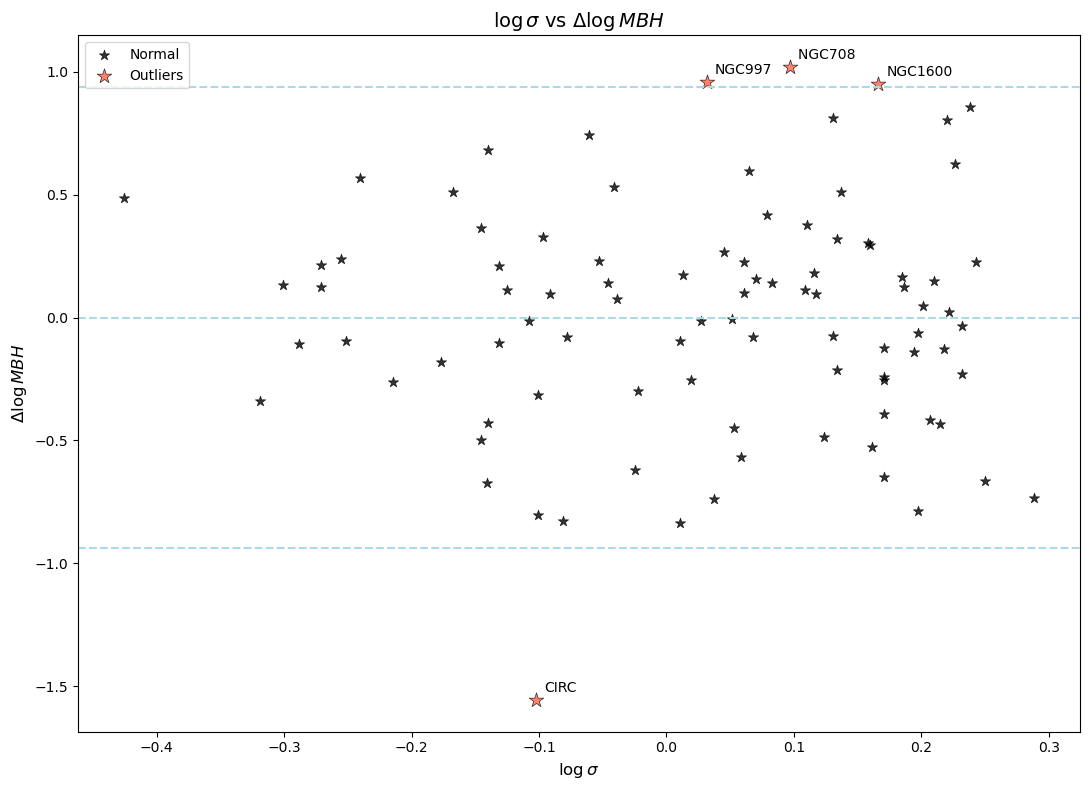

In [6]:

fig, ax = plt.subplots(figsize=(11, 8))
#ax.set_xscale("log")
#ax.set_yscale("log")
ax.set_xlabel("$\log \sigma$", fontsize=12)
ax.set_ylabel("$\Delta \log MBH$", fontsize=12)
ax.set_title("$\log \sigma$ vs $\Delta \log MBH$" , fontsize=14)


ax.scatter(log_sigma_full[~outlier_mask],delta_log_MBH[~outlier_mask],color="black", marker="*", s=60, alpha=0.8,
                   edgecolors="black", linewidths=0.5,label="Normal")
ax.scatter(log_sigma_full[outlier_mask],delta_log_MBH[outlier_mask],color="tomato", marker="*", s=120, alpha=0.8,
                   edgecolors="black", linewidths=0.5,label="Outliers")

for i,row in outliers.iterrows():
    plt.annotate(row["Galaxy"],
        (row["log σ"], row["Residual(dex)"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10 )
            
ax.axhline(y=0,linestyle="dashed",color="lightblue")
ax.axhline(y=2*rms, linestyle="dashed", color="lightblue")
ax.axhline(y=-2*rms, linestyle="dashed", color="lightblue")


ax.legend(loc="upper left", fontsize=10)
plt.tight_layout()
#plt.savefig("grafico_final.png", dpi=300, bbox_inches="tight")  
plt.show()


#print()

### (b) Two-panel figure

Now make a more complete two-panel figure. This is the version that could go on your poster.

**Top panel:** The full M–σ diagram, showing:
- All galaxies, with outliers marked in your distinct color and labeled
- The best-fit line for the full combined sample
- Shaded bands showing the 1σ and 2σ scatter regions around the fit
  - To draw a shaded band, use `ax.fill_between(x, y_lower, y_upper, alpha=0.15)`

**Bottom panel:** The residual plot from Step 2.1 (same x-axis, shared with the top panel)

To share the x-axis between the two panels, create your figure like this:
```python
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 8),
                                      sharex=True,
                                      gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.05})
```

Save the figure as `msigma_with_residuals.png` at 200 dpi.

> 💡 **Poster tip:** Font sizes should be at least 12–13 for axis labels on a poster figure. Use `fontsize=13` in your `set_xlabel`, `set_ylabel`, and `set_title` calls.

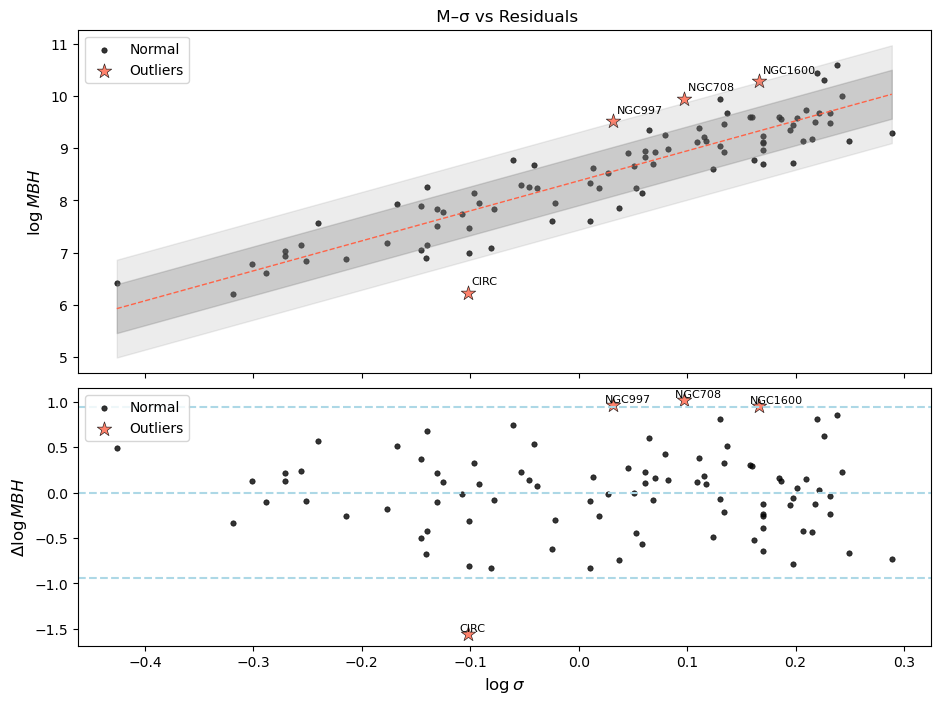

<Figure size 640x480 with 0 Axes>

In [36]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 8),
                                      sharex=True,
                                      gridspec_kw={'height_ratios': [4, 3], 'hspace': 0.05})

#ax.set_xscale("log")
#ax.set_yscale("log")

ax_top.set_ylabel("$\log MBH$", fontsize=12)
ax_top.set_title(" M–σ vs Residuals",fontsize=12)

ax_top.scatter(log_sigma_full[~outlier_mask],log_mbh_full[~outlier_mask],color="black", marker=".", s=60, alpha=0.8,
                   edgecolors="black", linewidths=0.5,label="Normal")
ax_top.scatter(log_sigma_full[outlier_mask],log_mbh_full[outlier_mask],color="tomato", marker="*", s=120, alpha=0.8,
                   edgecolors="black", linewidths=0.5,label="Outliers")


x = np.linspace(log_sigma_full.min(), log_sigma_full.max(), 200)
y=slope*x+intercept
ax_top.plot(x,y,color="tomato",linestyle="dashed",linewidth=1)

ax_top.fill_between(x, y-2*rms,y+2*rms, color="grey",alpha=0.15)
ax_top.fill_between(x,y-rms,y+rms, color="grey",alpha=0.30)

for i,row in outliers.iterrows():
    ax_top.annotate(row["Galaxy"],
        (row["log σ"], row["Measured log MBH"]),
        xytext=(3, 6),
        textcoords="offset points",
        fontsize=8 )



ax_top.legend(loc="upper left", fontsize=10)
#plt.tight_layout()
#plt.savefig("grafico_final.png", dpi=300, bbox_inches="tight")  



#ax.set_xscale("log")
#ax.set_yscale("log")
ax_bot.set_xlabel("$\log \sigma$", fontsize=12)
ax_bot.set_ylabel("$\Delta \log MBH$", fontsize=12)

ax_bot.scatter(log_sigma_full[~outlier_mask],delta_log_MBH[~outlier_mask],color="black", marker=".", s=60, alpha=0.8,
                   edgecolors="black", linewidths=0.5,label="Normal")
ax_bot.scatter(log_sigma_full[outlier_mask],delta_log_MBH[outlier_mask],color="tomato", marker="*", s=120, alpha=0.8,
                   edgecolors="black", linewidths=0.5,label="Outliers")

for i,row in outliers.iterrows():
    ax_bot.annotate(row["Galaxy"],
        (row["log σ"], row["Residual(dex)"]),
        xytext=(-6, 2),
        textcoords="offset points",
        fontsize=8 )
            
ax_bot.axhline(y=0,linestyle="dashed",color="lightblue")
ax_bot.axhline(y=2*rms, linestyle="dashed", color="lightblue")
ax_bot.axhline(y=-2*rms, linestyle="dashed", color="lightblue")


ax_bot.legend(loc="upper left", fontsize=10)
plt.show()
plt.savefig("msigma_with_residuals.png", dpi=200)  




## Part 3: Investigating outliers in the literature

De los 4 outliers que identificamos, los dos más interesantes para investigar son NGC 1600 (el over-massive más famoso) y Circinus (el under-massive más extremo). A continuación resumimos lo que dice la literatura sobre cada uno.

### Outlier 1: NGC 1600 — over-massive BH (residual = +0.95 dex)

**Contexto de la literatura:**

NGC 1600 es una galaxia elíptica relativamente aislada en un grupo pequeño. Thomas et al. (2016) usaron modelos orbitales triaxiales (triaxial Schwarzschild) con datos de Gemini/NIFS para medir una masa de BH de 17 mil millones de masas solares, una de las masas más precisas en ese régimen (rango de 15.5 a 18.5 × 10⁹ M_☉).

Lo sorprendente de NGC 1600 es que está en un entorno poco denso, un grupo pequeño, no un cúmulo masivo. Antes se pensaba que los BH tan masivos (>10¹⁰ M_☉) solo se encontraban en galaxias centrales de cúmulos ricos (como NGC 4889 en Coma o M87 en Virgo). NGC 1600 rompió ese paradigma.

¿Por qué es un outlier en M–σ?
- Su σ es relativamente bajo (293 km/s) comparado con su M_BH enorme. La relación M–σ predice ~5 × 10⁹ M_☉, pero el BH es 3 veces más masivo.
- Thomas et al. (2016) sugieren que NGC 1600 sufrió fusiones secas (dry mergers) que aumentaron la masa del BH sin aumentar σ proporcionalmente.
- También tiene un núcleo "diffuse core" (deficit de luz central), consistente con un escenario de fusión que sacaron estrellas del centro.

**Referencias:**
- Thomas, J. et al. 2016, ApJ, 833, L26 (arXiv:1604.01400)
- Comunicado de prensa UC Berkeley: "Supermassive black holes may be lurking everywhere in the universe" (2016)

---

### Outlier 2: Circinus — under-massive BH (residual = −1.56 dex)

**Contexto de la literatura:**

Circinus es la galaxia espiral Seyfert más cercana a la Vía Láctea (~4 Mpc). Su masa de BH fue medida con máseres de vapor de agua (H₂O masers) usando VLBI, que es uno de los métodos más precisos para medir M_BH en galaxias activas (Greenhill et al. 2003).

¿Por qué es un outlier en M–σ?
La relación M–σ predice ~5 × 10⁷ M_☉ para su σ = 158 km/s, pero su BH es 30 veces menos masivo (1.7 × 10⁶ M_☉).
Circinus es una galaxia espiral tardía (Sb/Sc) con un pseudobulge, no un bulge clásico. Kormendy & Ho (2013) argumentan que la relación M–σ es diferente para pseudobulges vs. bulges clásicos, los pseudobulges tienden a tener BHs menos masivos.
El método del maser mide el disco molecular interno (sub-pc), que puede no representar bien σ del bulge global.

Nota?: Circinus podría no ser un outlier "real" en el sentido físico, sino que cae en una población distinta (pseudobulges) que no sigue la misma relación M–σ que los bulges clásicos. Esto es consistente con la diferencia que encontraron McConnell & Ma (2013) entre early-type (α=8.39) y late-type (α=8.07) galaxies.

**Referencias:**
- Greenhill, L. et al. 2003, ApJ, 590, 162 (medición original del maser)
- Kormendy, J. & Ho, L. 2013, ARA&A, 51, 511 (pseudobulges y M–σ)
- McConnell & Ma 2013, ApJ, 764, 184 (este paper)

---

## Part 4: What do the outliers tell us about the high-mass end?


### Patrones que observamos

1. 3 de los 4 outliers son over-massive (residuales positivos). Esto significa que, para sus σ, tienen BHs más masivos de lo esperado.

2. 3 de los 4 outliers son ETGs (E) y provienen de la muestra New (survey MASSIVE + papers recientes). Esto confirma que el extremo de altas masas de la relación M–σ está dominado por elipsales masivas con masas de BH inciertas.

3. El único under-massive es Circinus, que es una galaxia espiral tardía (LTG) medida con maser. Esto es consistente con el hallazgo de que los pseudobulges siguen una relación M–σ distinta (Kormendy & Ho 2013).

4. NGC 708 y NGC 997 son galaxias del survey MASSIVE con mediciones recientes de masa de BH (de Nicola 2024, Dominiak 2024). Sus residuales positivos pueden reflejar que las nuevas mediciones dinámicas (con modelos triaxiales) tienden a dar masas más altas que las mediciones antiguas.

### ¿Qué nos dicen los outliers sobre el extremo de altas masas?

El hecho de que los outliers over-massive sean todos galaxias elípticas muy masivas medidas con métodos recientes sugiere varias cosas:

- El scatter aumenta en el extremo de altas masas, como ya reportó McConnell & Ma (2013). Nuestro rms de 0.47 dex (vs. 0.38 dex del paper) confirma esto al agregar más galaxias masivas.

- La relación M–σ puede no ser una sola ley de potencias en todo el rango de masas. Varios autores (e.g., McConnell & Ma 2013; Marsden et al. 2020) han sugerido que la relación se empina al alto σ, lo que sería consistente con ver galaxias over-massive en ese régimen.

- Las masas de BH en galaxias muy masivas son intrínsecamente más inciertas, porque requieren modelos dinámicos complejos (orbitales triaxiales) y porque las galaxias tienen perfiles de brillo superficial complicados. Parte del scatter puede ser observacional, no físico.

- Procesos como las fusiones secas (dry mergers) pueden desacoplar el crecimiento del BH del crecimiento del bulge, produciendo galaxias con BHs "over-massive" para su σ. NGC 1600 es un ejemplo paradigmático de esto (Thomas et al. 2016).

### Conclusión

Nuestro análisis de outliers muestra que la relación M–σ no es uniformemente válida en todo el rango de masas. En el extremo de altas masas, la relación se vuelve más dispersa y varias galaxias se desvían significativamente, ya sea por razones físicas (fusiones, pseudobulges) o observacionales (incertidumbres en los modelos dinámicos). Esto motiva el uso de métodos de regresión más sofisticados (como MPFITEXY o LINMIX_ERR que consideran errores en ambos ejes y scatter intrínseco) para futuras análisis, en lugar de un simple np.polyfit que usamos aquí.